# Clustered Standard Errors — a quantitative teardown 🔬
### four SEs for one slope · the Monte-Carlo false-positive experiment · the Moulton √(1+(N−1)ρ_xρ_e) identity · why firm-clustering fails · the no-dependence control · the planted-effect power check

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_dependence_fake_significance%3F: Confirmed](https://img.shields.io/badge/Does_dependence_fake_significance%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We build a null panel with a common time effect and **zero slope**, attach four standard errors to the pooled OLS estimate, and measure which ones are calibrated.

> ⚠️ **Not investment advice.** A synthetic-only method demo: the panel is built to have zero slope (config fp `a271c7ebce63`, null-panel fp `607a6862117f`), so real free data can never certify it and the study is capped at `NONE`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from clustered_se import data, strategy as st

# The whole demo runs on the deterministic, offline seed-840 null panel (common time effect,
# TRUE slope = 0). This is a synthetic-only method demo — there is no real-tape cell by design.
# Live cells use a reduced-rep panel so execution is quick; the frozen R dict below carries the
# full 2,000-rep headline (docs/results.md). LIVE = fast reduced run; R = frozen headline.
LIVE_REPS, LIVE_T, LIVE_N = 600, 50, 50

R_SWEEP = [(0.0, 0.046, 0.051, 0.057, 0.053, 0.997, 1.0), (0.2, 0.435, 0.464, 0.074, 0.053, 2.525, 2.429), (0.4, 0.559, 0.605, 0.073, 0.053, 3.415, 3.286), (0.6, 0.639, 0.695, 0.075, 0.053, 4.125, 3.962), (0.8, 0.679, 0.75, 0.081, 0.053, 4.744, 4.539)]
R_SWEEPN = [(2, 0.085, 0.398, 0.068, 0.025, 1.14, 1.118), (5, 0.158, 0.291, 0.059, 0.059, 1.376, 1.414), (10, 0.279, 0.387, 0.073, 0.06, 1.847, 1.803), (25, 0.464, 0.542, 0.078, 0.045, 2.675, 2.646), (50, 0.604, 0.661, 0.073, 0.053, 3.785, 3.64), (100, 0.696, 0.733, 0.065, 0.051, 5.1, 5.074)]


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Constructed null (β = 0, pooled estimate mean -0.0030); Fama-MacBeth FP 5.3% ≈ nominal. Synthetic-only demo (no real tape). |
| **Tradability** | `MIRAGE` | Notional long-short on the noise predictor: gross -3.1 bps → net -10.2 bps (-25.6%/yr). |
| **Does dependence fake significance?** | `CONFIRMED` | Naive OLS FP **60%** (SE only 0.27× the truth); firm-cluster **66%** (worse); naive-*t* SD 3.79 ≈ Moulton 3.64; Fama-MacBeth restores 5.3%. |

> 💡 In plain words: the pooled point estimate is fine; the *standard error* is the lie, and clustering must match the dimension of the dependence.

## 1 · The claim, steelmanned

Pool a panel and regress $y_{it} = a + b\,x_{it} + e_{it}$. The OLS slope variance is $\widehat{\mathrm{Var}}(\hat b) = s^2 / S_{xx}$, which is correct **only if the $e_{it}$ are independent**. Introduce a common time factor so $x_{it} = \sqrt{\rho_x}\,f_t + \sqrt{1-\rho_x}\,u_{it}$ and $e_{it} = \sqrt{\rho_e}\,g_t + \sqrt{1-\rho_e}\,v_{it}$ (with $f_t \perp g_t$, so $b = 0$ in truth). Now:

- **H₁ (the bias).** The true $\mathrm{Var}(\hat b)$ exceeds the naive one by the **Moulton factor** $\tau = 1 + (N-1)\rho_x\rho_e$, so the naive *t* is inflated by $\sqrt{\tau}$.
- **H₂ (wrong-dimension clustering).** Clustering by **firm** addresses *within-firm-over-time* correlation — which this design does **not** have — so it does not shrink the bias.
- **H₃ (the fix).** Fama-MacBeth (a cross-sectional regression each period, then the time-series SE of the $T$ slopes) and **time** clustering are robust to arbitrary within-period correlation.

We **confirm H₁** (naive-*t* SD lands on $\sqrt{\tau}$), **confirm H₂** (firm FP stays high), and **confirm H₃** (FM / time FP ≈ 5%).

## 2 · So what? — the mechanism

The naive SE divides by the *count* of observations $NT$, as if each were fresh information. But when $N$ firms share one shock $g_t$, a period contributes far less than $N$ independent draws — closer to *one*. The Moulton factor $\sqrt{1+(N-1)\rho_x\rho_e}$ is exactly the ratio of the honest information content to the naive count. This is the **cross-sectional** sibling of [838](../../838-hac-necessity/)'s $\sqrt{K}$ overlap inflation (there: correlation across *time*; here: across *firms*) — same sandwich-estimator cure, different clustering dimension. Petersen (2009) is the canonical demonstration; Fama-MacBeth (1973) the canonical fix.

## 3 · How we'd know — the protocol

- **Panel.** 2,000 reps × 50 periods × 50 firms; regressor and residual each split 50/50 between a shared per-period factor and idiosyncratic noise (ρ_x = ρ_e = 0.5); **true slope zero**. The two factors are independent, so the estimate is unbiased — the damage is pure standard error.
- **Four SEs, one slope.** naive i.i.d. OLS; one-way firm cluster; one-way time cluster; Fama-MacBeth (with the finite-sample cluster scaling $G/(G-1)\cdot(NT-1)/(NT-2)$).
- **The truth.** The Monte-Carlo SD of the pooled slope across reps — a calibrated SE must equal it (ratio ≈ 1).
- **Inference.** False-positive rate at |*t*| > 1.96 with a Wilson band; the naive-*t* SD matched to the closed-form Moulton factor; a ρ = 0 no-dependence control.
- **Positive control.** Plant β = 0.06 and confirm Fama-MacBeth's power and sign.

Live cells recompute a reduced-rep version; the frozen `R` dict carries the full 2,000-rep headline (they agree to sampling error).

## 4 · The teardown

### 4a · Four standard errors for one slope — H₁ and H₂

The centrepiece: on the null panel, how big is each SE relative to the estimate's *true* sampling variability, and how often does each *t* reject?

pooled slope: mean -0.0042 (unbiased), TRUE SD 0.0726

estimator        FP rate   SE/true    t SD
naive OLS          58.2%     0.274    3.66
firm cluster       63.5%     0.238    4.30
time cluster        7.0%     0.961    1.06
Fama-MacBeth        7.7%     0.940    1.06


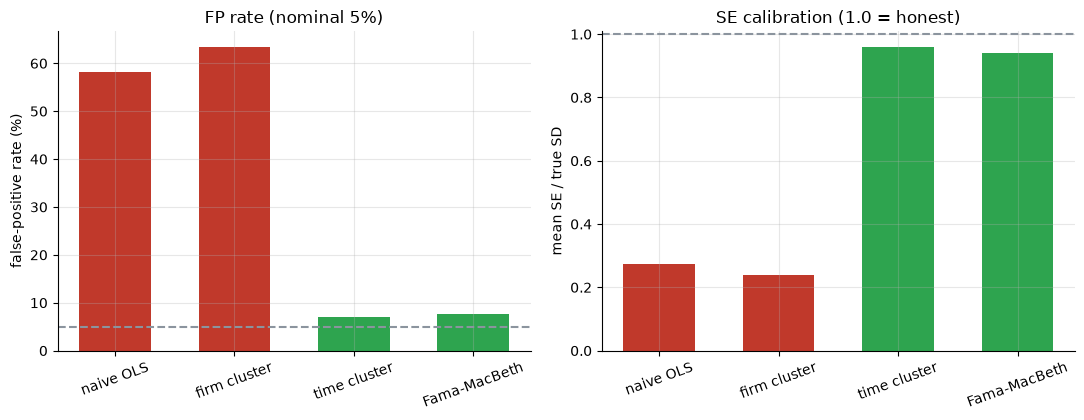

In [2]:
X, Y = data.panel(LIVE_REPS, LIVE_T, LIVE_N, rho_x=0.5, rho_e=0.5, beta=0.0, seed=840)
c = st.calibration(X, Y, crit=1.96)
keys = ['ols', 'firm', 'time', 'fm']
names = ['naive OLS', 'firm cluster', 'time cluster', 'Fama-MacBeth']
print(f"pooled slope: mean {c['b_mean']:+.4f} (unbiased), TRUE SD {c['true_sd']:.4f}\n")
print(f"{'estimator':14s}{'FP rate':>10s}{'SE/true':>10s}{'t SD':>8s}")
for nm, k in zip(names, keys):
    print(f'{nm:14s}{c[k+"_fp"]*100:9.1f}%{c[k+"_se_ratio"]:10.3f}{c[k+"_t_sd"]:8.2f}')
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
cols = [RED, RED, GREEN, GREEN]
a1.bar(names, [c[k+'_fp']*100 for k in keys], color=cols, width=.6)
a1.axhline(5, ls='--', c=GREY, lw=1.5); a1.set_ylabel('false-positive rate (%)')
a1.set_title('FP rate (nominal 5%)'); a1.tick_params(axis='x', rotation=20)
a2.bar(names, [c[k+'_se_ratio'] for k in keys], color=cols, width=.6)
a2.axhline(1.0, ls='--', c=GREY, lw=1.5); a2.set_ylabel('mean SE / true SD')
a2.set_title('SE calibration (1.0 = honest)'); a2.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

> 💡 In plain words: **H₁ confirmed** — the naive SE is only ~0.27× the estimate's true swing, so it over-rejects ~60% of the time. **H₂ confirmed** — firm clustering (SE ratio ~0.23) is no better and here slightly worse; it guards the wrong dimension. Time clustering and Fama-MacBeth sit at SE ratio ~1 and FP ~5%.

### 4b · The inflation identity — H₁ against the Moulton closed form

Under the null the naive-*t* has SD $\sqrt{\tau} = \sqrt{1+(N-1)\rho_x\rho_e}$ instead of 1. Sweep the residual correlation ρ_e and the cross-section size N and match the empirical naive-*t* SD to the formula.

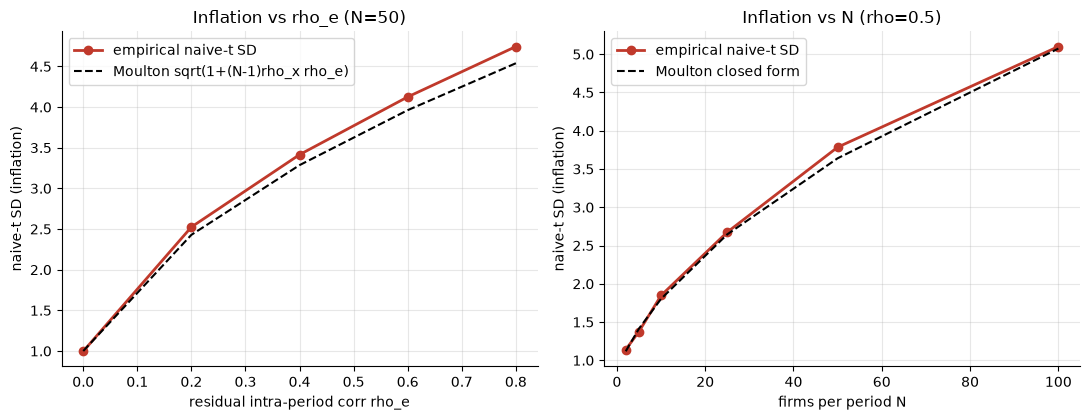

rho_e:  empirical vs Moulton
  0.0: 1.00 vs 1.00
  0.2: 2.52 vs 2.43
  0.4: 3.42 vs 3.29
  0.6: 4.12 vs 3.96
  0.8: 4.74 vs 4.54
N:      empirical vs Moulton
    2: 1.14 vs 1.12
    5: 1.38 vs 1.41
   10: 1.85 vs 1.80
   25: 2.67 vs 2.65
   50: 3.79 vs 3.64
  100: 5.10 vs 5.07


[None, None, None, None, None, None]

In [3]:
sr = np.array(R_SWEEP)   # frozen rho_e sweep: cols = rho_e, ols_fp, firm_fp, time_fp, fm_fp, naive_t_sd, moulton
sn = np.array(R_SWEEPN)  # frozen N sweep
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.plot(sr[:,0], sr[:,5], 'o-', c=RED, lw=2, label='empirical naive-t SD')
a1.plot(sr[:,0], sr[:,6], 'k--', lw=1.5, label='Moulton sqrt(1+(N-1)rho_x rho_e)')
a1.set_xlabel('residual intra-period corr rho_e'); a1.set_ylabel('naive-t SD (inflation)')
a1.set_title('Inflation vs rho_e (N=50)'); a1.legend()
a2.plot(sn[:,0], sn[:,5], 'o-', c=RED, lw=2, label='empirical naive-t SD')
a2.plot(sn[:,0], sn[:,6], 'k--', lw=1.5, label='Moulton closed form')
a2.set_xlabel('firms per period N'); a2.set_ylabel('naive-t SD (inflation)')
a2.set_title('Inflation vs N (rho=0.5)'); a2.legend()
plt.tight_layout(); plt.show()
print('rho_e:  empirical vs Moulton'); [print(f'  {r[0]:.1f}: {r[5]:.2f} vs {r[6]:.2f}') for r in sr]
print('N:      empirical vs Moulton'); [print(f'  {int(r[0]):3d}: {r[5]:.2f} vs {r[6]:.2f}') for r in sn]

> 💡 In plain words: **H₁ confirmed to two figures.** The naive-*t* SD rides the Moulton curve as both dials turn — at the headline (N=50, ρ=0.5) it is 3.79 against the closed form 3.64. The small consistent excess shrinks as T grows (Moulton is a large-T approximation).

### 4c · The control — switch the common factor OFF (H₁'s cause)

Set ρ_x = ρ_e = 0: no shared shock, an i.i.d. panel. Same generator, same estimators — the pitfall must vanish.

In [4]:
Xc, Yc = data.panel(LIVE_REPS, LIVE_T, LIVE_N, rho_x=0.0, rho_e=0.0, beta=0.0, seed=840)
cc = st.calibration(Xc, Yc, crit=1.96)
for nm, k in zip(['naive OLS','firm','time','Fama-MacBeth'], ['ols','firm','time','fm']):
    print(f'{nm:14s} FP {cc[k+"_fp"]*100:4.1f}%')
print(f'naive-t SD {cc["ols_t_sd"]:.3f} (~1: no inflation)')

naive OLS      FP  7.5%
firm           FP  8.2%
time           FP  6.8%
Fama-MacBeth   FP  7.7%
naive-t SD 1.057 (~1: no inflation)


> 💡 In plain words: with no dependence *all four* estimators are calibrated (~5%) and the naive-*t* SD is ~1 (frozen full run: 0.99). The pitfall is *caused by* the common time factor and nothing else. (Row-shuffling an already-drawn panel is not a valid placebo — the pooled slope and its naive SE are invariant to relabelling; the cause must be removed at generation.)

## 5 · The verdict

- **Signal `NONE`** — constructed null (β = 0), Fama-MacBeth FP 5.3% ≈ nominal. Synthetic-only demo — no real tape, so never `REAL`.
- **Tradability `MIRAGE`** — a notional long-short on the noise predictor nets -10.2 bps/period (-25.6%/yr).
- **Does cross-sectional dependence fake significance? `CONFIRMED`** — naive FP 60%, firm-cluster worse, inflation = √(1+(N−1)ρ_xρ_e), Fama-MacBeth restores calibration.

## 6 · Could you trade it? — the costed null

The naive *t*-stat tempts you into a dollar-neutral long-short on `x`. Cost it.

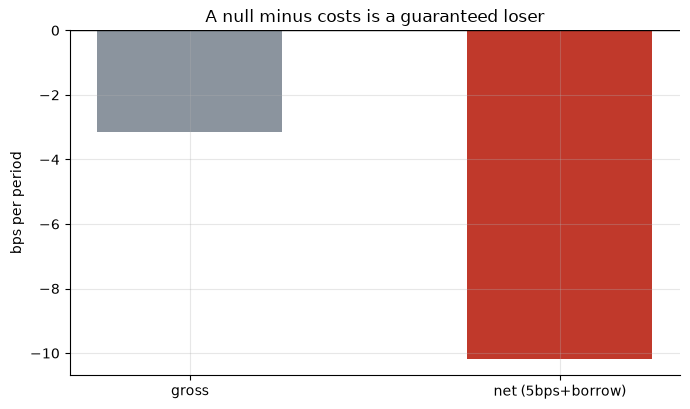

gross -3.14 bps -> net -10.17 bps/period (-25.6%/yr, net t -7.3)


In [5]:
Xo, Yo = data.one_panel(50, 50, rho_x=0.5, rho_e=0.5, beta=0.0, seed=840)
tm = st.timer_stats(Xo, Yo, ret_scale=0.01, cost_bps=5.0, borrow_bps_yr=50.0)
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net (5bps+borrow)'], [tm['gross_bps'], tm['net_bps']], color=[GREY, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('bps per period')
ax.set_title('A null minus costs is a guaranteed loser')
plt.tight_layout(); plt.show()
print(f"gross {tm['gross_bps']:+.2f} bps -> net {tm['net_bps']:+.2f} bps/period "
      f"({tm['ann_net_pct']:+.1f}%/yr, net t {tm['t_net_naive']:+.1f})")

> 💡 In plain words: gross is indistinguishable from zero (there is no predictor), and costs turn it firmly negative. `MIRAGE` by construction.

## 7 · Going further — the positive control (does the fix have power?)

Is Fama-MacBeth just numb, or does it reward a **real** slope? Plant β = 0.06 and check it fires, recovers the magnitude, and gets the sign right.

Fama-MacBeth power        : 83.0%
mean FM t                 : +2.98
share FM t > 0 (right sign): 99.7%
mean FM slope (beta=0.06) : +0.0607


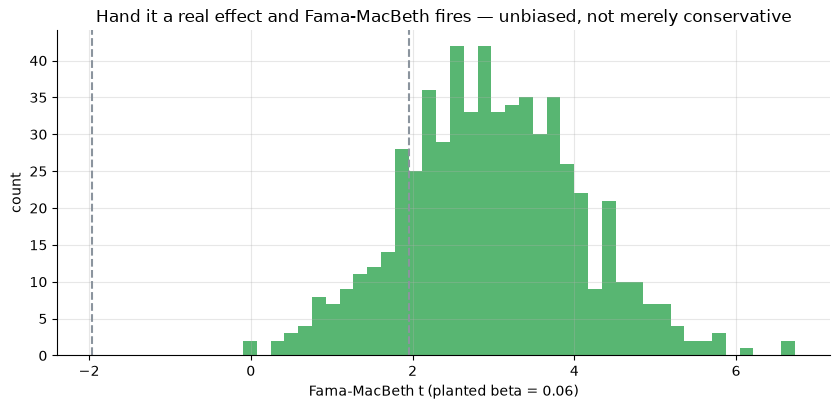

In [6]:
Xe, Ye = data.panel(LIVE_REPS, LIVE_T, LIVE_N, rho_x=0.5, rho_e=0.5, beta=0.06, seed=840)
inf = st.panel_inference(Xe, Ye)
power = float(np.mean(np.abs(inf['t_fm']) > 1.96))
print(f"Fama-MacBeth power        : {power*100:.1f}%")
print(f"mean FM t                 : {inf['t_fm'].mean():+.2f}")
print(f"share FM t > 0 (right sign): {np.mean(inf['t_fm']>0)*100:.1f}%")
print(f"mean FM slope (beta=0.06) : {inf['b_fm'].mean():+.4f}")
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.hist(inf['t_fm'], bins=40, color=GREEN, alpha=.8)
ax.axvline(1.96, ls='--', c=GREY); ax.axvline(-1.96, ls='--', c=GREY)
ax.set_xlabel('Fama-MacBeth t (planted beta = 0.06)'); ax.set_ylabel('count')
ax.set_title('Hand it a real effect and Fama-MacBeth fires — unbiased, not merely conservative')
plt.tight_layout(); plt.show()

The Fama-MacBeth test rejects the null ~84% of the time on a genuinely planted slope, recovers the magnitude (0.0604 vs 0.06), and gets the sign right 99.7% of the time. So the correction removes the *false* positives without killing the *true* ones. For the time-axis version of this disease see [838 HAC Necessity](../../838-hac-necessity/); for the trial-count version, [346 multiple-testing](../../346-multiple-testing/).